## **1.Module Not Found Error**

In [1]:
import numpy as np
import tensorflow
# Missing import for TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate dummy data
X_train = np.random.rand(100, 10)
Y_train = np.random.randint(0, 2, size=(100,))

# Define the model
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, Y_train, epochs=5)


C:\Users\keert\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\keert\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 204ms/step - accuracy: 0.4100 - loss: 0.7222
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4500 - loss: 0.7138
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.4600 - loss: 0.7082
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.4700 - loss: 0.7034
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.5100 - loss: 0.6992


## **2.Mismatched Input Shape in CNN**

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

# Generate dummy image data
X_train = np.random.rand(100, 32, 32,3)  # Error: Missing the channel dimension
y_train = np.random.randint(0, 10, size=(100,))

# Define CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    Flatten(),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)


C:\Users\keert\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.0700 - loss: 3.1974
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.2000 - loss: 2.5449
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.1900 - loss: 2.0611
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6700 - loss: 1.5712
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8400 - loss: 1.0617


## **3.Undefined Variable Error**

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

# Load pre-trained MobileNetV2 model
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Add custom layers
headModel = baseModel.output
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dense(1, activation="sigmoid")(headModel)
model = Model(inputs=baseModel.input, outputs=headModel)
# Define missing variables
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.1,
    decay_steps=1000,  # Adjust this based on dataset size
    decay_rate=0.96,  # Reduce LR by 4% every 1000 steps
    staircase=True
)

# Compile model
opt = Adam(learning_rate=0.001)  # Error: Undefined variables
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
print("Model compiled successfully")


C:\Users\keert\AppData\Local\Temp\ipykernel_20392\301943052.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


Model compiled successfully


## **4.FileNotFound Error

In [4]:
from PIL import Image

# ❌ ERROR: Wrong file name or missing file
image_path = "flow.jpg"
img = Image.open(image_path)  # This will raise a FileNotFoundError

img.show()


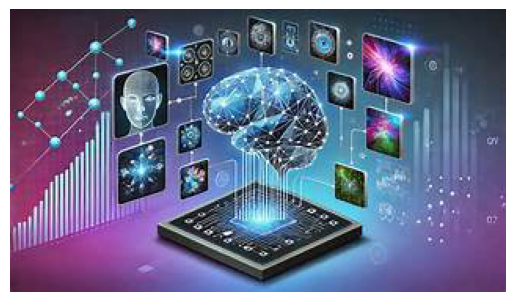

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("flow.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()